# 🦠 Analisi del Dataset COVID-19

Utilizzando il **file CSV fornito**, convertire i dati in **DataFrame** ed eseguire le seguenti operazioni:

## 5️⃣ Grafico a linee dei principali indicatori
**File da utilizzare:** COVID_01-01-2021.csv

- Creare un **grafico a linee** che mostri:
  - ✅ Casi confermati
  - ❌ Decessi totali
  - 💚 Pazienti recuperati
- Confrontare solo i paesi con **più di 150 decessi**
- 📊 Visualizzare le tendenze per i principali indicatori COVID

## 6️⃣ Casi confermati nel primo trimestre 2021
**File da utilizzare:** COVID_01-01-2021.csv e file dei mesi successivi

- Creare un programma che visualizzi i **casi confermati di coronavirus** durante il **primo trimestre del 2021**
- 📈 Visualizzare i dati in un **grafico chiaro** con un **titolo significativo**
- 🔍 Analizzare l'andamento generale dei casi nei primi tre mesi dell'anno

## 5️⃣ Grafico a linee dei principali indicatori
**File da utilizzare:** COVID_01-01-2021.csv

- Creare un **grafico a linee** che mostri:
  - ✅ Casi confermati
  - ❌ Decessi totali
  - 💚 Pazienti recuperati
- Confrontare solo i paesi con **più di 150 decessi**
- 📊 Visualizzare le tendenze per i principali indicatori COVID

Colonne disponibili nel file: ['FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Last_Update', 'Lat', 'Long_', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'Combined_Key', 'Incident_Rate', 'Case_Fatality_Ratio']


<Figure size 1800x1000 with 0 Axes>

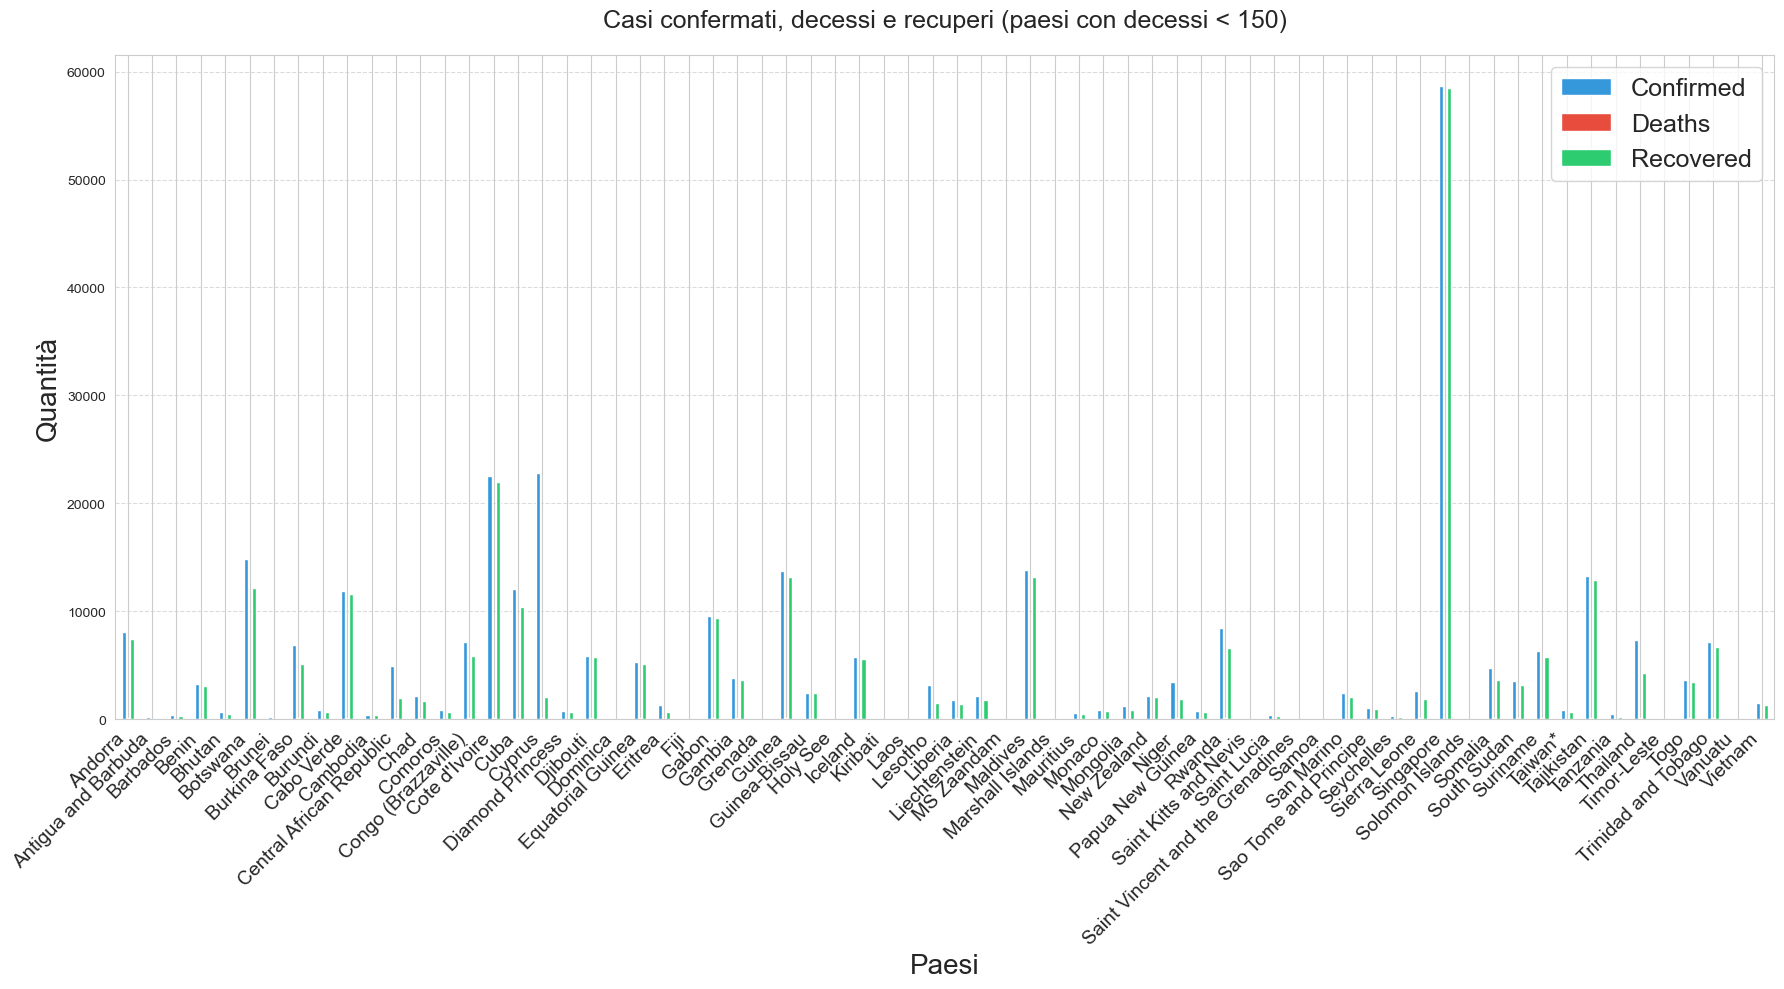

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Aggiungo seaborn per migliorare l'estetica

# Imposto uno stile più moderno per i grafici
sns.set_style("whitegrid")

# Caricare il file CSV in un DataFrame
file_csv = "COVID_01-01-2021.csv"

try:
    df = pd.read_csv(file_csv)

    # Mostrare le colonne disponibili (per verifica)
    print("Colonne disponibili nel file:", df.columns.tolist())

    # Assicurarsi che le colonne siano corrette
    colonne = ['Country_Region', 'Confirmed', 'Deaths', 'Recovered', 'Active']
    if all(col in df.columns for col in colonne):
        # Raggruppare i dati per paese e calcolare i totali
        totali_paese = df.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum()

        # Filtrare i paesi con meno di 150 decessi
        filtrati = totali_paese[totali_paese['Deaths'] < 150]
        
        # Impostare il grafico
        plt.figure(figsize=(18, 10)) 
        
        # Creare il grafico a barre con colori più distinti
        ax = filtrati[['Confirmed', 'Deaths', 'Recovered']].plot(
            kind='bar', 
            figsize=(18, 10),
            color=['#3498db', '#e74c3c', '#2ecc71'])  # Colori più vivaci
        
        # Migliorato il titolo e le etichette
        plt.title('Casi confermati, decessi e recuperi (paesi con decessi < 150)', fontsize=18, pad=20)
        plt.xlabel('Paesi', fontsize=20)
        plt.ylabel('Quantità', fontsize=20)
        
        # Migliorata la leggibilità delle etichette sull'asse x
        plt.xticks(rotation=45, ha='right', fontsize=14)
        
        # Aggiunta una legenda
        plt.legend(fontsize=18, loc='upper right')
        
        # Aggiunta una griglia per facilitare la lettura dei valori
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Il file non contiene le colonne previste: {colonne}. Verifica i nomi delle colonne nel file.")

except FileNotFoundError:
    # Gestisce il caso in cui il file specificato non esiste nel percorso indicato
    # Questo può accadere se il nome del file è sbagliato o se il file è stato spostato
    print(f"Il file '{file_csv}' non è stato trovato. Assicurati che sia nella stessa cartella di questo script.")
    
except pd.errors.EmptyDataError:
    # Gestisce il caso in cui il file esiste ma è vuoto o non contiene dati leggibili
    # Aiuta a distinguere tra file mancanti e file esistenti ma vuoti
    print(f"Il file '{file_csv}' è vuoto o non contiene dati validi.")
    
except pd.errors.ParserError:
    # Gestisce errori di parsing, ad esempio quando il formato del file non è corretto
    # o quando ci sono problemi con i delimitatori o la struttura del CSV
    # ad esempio: delimitatori errati, virgolette non bilanciate, o formattazione non standard
    print(f"Si è verificato un problema nell'analisi del file '{file_csv}'. Verifica che sia un CSV valido.")
    
except Exception as e:
    # Cattura qualsiasi altro errore non previsto dall'eccezione precedente
    # Ad esempio, problemi di permessi, errori di lettura del file, o errori durante l'elaborazione dei dati
    # Fornisce un messaggio generico con i dettagli dell'errore per facilitare il debug:
    print(f"Si è verificato un errore imprevisto: {e}")

## 6️⃣ Casi confermati nel primo trimestre 2021
**File da utilizzare:** COVID_01-01-2021.csv e file dei mesi successivi

- Creare un programma che visualizzi i **casi confermati di coronavirus** durante il **primo trimestre del 2021**
- 📈 Visualizzare i dati in un **grafico chiaro** con un **titolo significativo**
- 🔍 Analizzare l'andamento generale dei casi nei primi tre mesi dell'anno

<Figure size 1200x700 with 0 Axes>

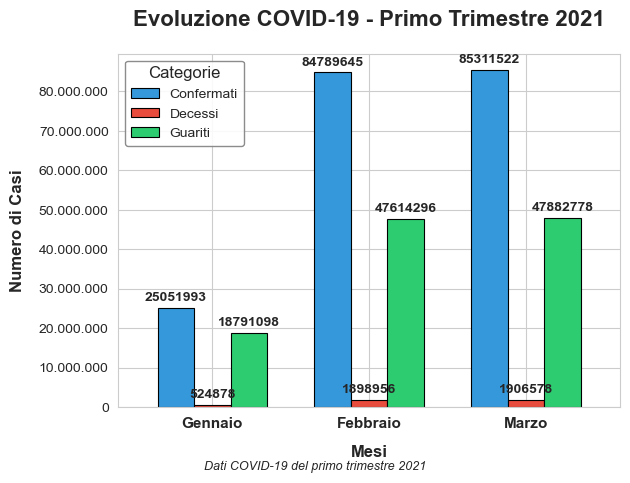

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Caricamento dei dati
files = [
    "COVID_01-01-2021.csv",
    "COVID_01-02-2021.csv",
    "COVID_01-03-2021.csv"
]

# Lista per memorizzare i DataFrame
dataframes = []

# Elaborare e correggere manualmente le date
for file in files:
    df = pd.read_csv(file)
    
    # Correggere manualmente le date se sono vuote o errate
    if "COVID_01-02-2021" in file:
        df['Last_Update'] = '2021-02-01'
    elif "COVID_01-03-2021" in file:
        df['Last_Update'] = '2021-03-01'
    
    df['Last_Update'] = pd.to_datetime(df['Last_Update'], errors='coerce')
    df['Mese'] = df['Last_Update'].dt.month_name(locale='en')  # Aggiungere il nome del mese
    dataframes.append(df)

# Combinare tutti i dati
data = pd.concat(dataframes, ignore_index=True)

# Raggruppare per mese
riepilogo = data.groupby('Mese')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Ordinare i mesi
mesi_ordinati = ['January', 'February', 'March']  # Nomi in inglese come generati da month_name()
riepilogo = riepilogo.reindex(mesi_ordinati)

# Traduzione dei mesi in italiano per la visualizzazione
mesi_tradotti = ['Gennaio', 'Febbraio', 'Marzo']
riepilogo.index = mesi_tradotti

# Impostare lo stile di seaborn per un aspetto più moderno
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# Colori personalizzati più gradevoli
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Creare il grafico a barre con miglioramenti estetici
ax = riepilogo.plot(kind='bar', width=0.7, color=colors, edgecolor='black', linewidth=0.8)

# Aggiungere etichette con i valori sopra ogni barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10, fontweight='bold', padding=3)

# Migliorare il titolo e le etichette
plt.title('Evoluzione COVID-19 - Primo Trimestre 2021', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mesi', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Numero di Casi', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.yticks(fontsize=10)

# Formattare i numeri sull'asse y con separatori delle migliaia
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', '.')))

# Personalizzare la legenda
plt.legend(['Confermati', 'Decessi', 'Guariti'], 
           title='Categorie', 
           title_fontsize=12,
           fontsize=10, 
           loc='upper left', 
           frameon=True, 
           framealpha=0.9,
           edgecolor='gray')

# Aggiungere una nota a piè di pagina
plt.figtext(0.5, 0.01, 'Dati COVID-19 del primo trimestre 2021', ha='center', fontsize=9, fontstyle='italic')

# Migliorare il layout
plt.tight_layout()

# Mostrare il grafico
plt.show()